<div style="
    padding: 32px 36px;
    border-radius: 16px;
    background: linear-gradient(135deg, #102A43 0%, #243B53 100%);
    color: #F7F4EC;
    margin-bottom: 24px;
">
    <div style="font-size: 13px; letter-spacing: 0.16em; text-transform: uppercase; color: #D4A44C; font-weight: 700;">
        ConflictLens · Article validation notebook
    </div>
    <h1 style="margin: 10px 0 8px 0; font-size: 38px; font-weight: 700; color: #FFFFFF;">
        Seven years out of thirty-seven. Half the toll.
    </h1>
    <p style="margin: 0; max-width: 860px; font-size: 17px; line-height: 1.55; color: #D9E2EC;">
        Lightweight, article-specific notebook that recalculates the figures and headline numbers used in the draft from the validated ConflictLens analysis-ready panel.
    </p>
    <div style="margin-top: 24px; padding-top: 16px; border-top: 1px solid rgba(255,255,255,0.20); font-size: 13px; color: #BCCCDC;">
        UCDP OV · GED event composition · annual concentration · contributor ≠ perpetrator
    </div>
</div>

## 0. Purpose and scope

This notebook is intentionally narrow. It does **not** rebuild the panel and does **not** reproduce the broad Notebook 03 analysis. Its only purpose is to recalculate and export the figures and numbers used by the article **"Seven years out of thirty-seven. Half the toll."**

**Input contract**

- Source: `02_analysis_unit_year_panel_analysis_ready.parquet`.
- Analytical grain: `analysis_unit_id + year`.
- Main metric: `ucdp_ov_total_deaths_best_zf`.
- Period: 1989–2025.
- Universe: `analysis_conflict_universe == True` and `unit_exists_in_year == True`.

**Guardrails kept throughout the notebook**

1. A country-year contributor is a statistical contributor, **not** a perpetrator attribution.
2. `0` and `NA` are not semantically identical; this notebook uses the curated `_zf` metrics only after filtering out pre-existence rows.
3. The notebook is descriptive: no causal claim, no prediction, no operational inference.
4. Israel 2025 is reported only as a raw statistical contributor. It is deliberately excluded from GED-type categorisation charts.

## Navigation

1. [Environment and input](#environment-input)
2. [Annual curve and the 7-year concentration result](#annual-curve)
3. [Country-year concentration](#country-year-concentration)
4. [Peak-year contributors and Israel 2025](#peak-contributors)
5. [GED event composition for selected peaks](#ged-composition)
6. [Intensity versus diffusion](#intensity-diffusion)
7. [Export manifest and validation checks](#manifest-validation)

<a id="environment-input"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 1</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Environment and input</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Load the validated panel, set export folders and enforce the article input contract.</p>
</div>

In [1]:
from __future__ import annotations

import importlib.metadata as importlib_metadata
import importlib.util
import json
import math
import platform
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

REQUIRED_MODULES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "pyarrow": "pyarrow",
}

missing = [module for module in REQUIRED_MODULES if importlib.util.find_spec(module) is None]
if missing:
    packages = " ".join(REQUIRED_MODULES[module] for module in missing)
    raise ImportError(
        "Missing required package(s): " + ", ".join(missing) + "\n\n"
        "Install the missing packages directly:\n"
        f"    python -m pip install {packages}"
    )

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd()
if not any((PROJECT_ROOT / name).exists() for name in ["outputs", "02_analysis_unit_year_panel_analysis_ready.parquet"]):
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / "outputs").exists() or (candidate / "02_analysis_unit_year_panel_analysis_ready.parquet").exists():
            PROJECT_ROOT = candidate
            break

OUTPUT_ROOT = PROJECT_ROOT / "03bis_seven_years_article_outputs"
FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
for folder in [OUTPUT_ROOT, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "03bis_seven_years"

PALETTE = {
    "navy": "#102A43",
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "purple": "#B279A2",
    "brown": "#9D755D",
    "gray": "#6B7280",
}

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 120,
})

package_versions = {module: importlib_metadata.version(package) for module, package in REQUIRED_MODULES.items()}


def fmt_int(value: float | int | None) -> str:
    if value is None or pd.isna(value):
        return "NA"
    return f"{float(value):,.0f}".replace(",", " ")


def fmt_pct(value: float | int | None, decimals: int = 1) -> str:
    if value is None or pd.isna(value):
        return "NA"
    return f"{float(value) * 100:.{decimals}f}%"


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_fig(fig: plt.Figure, filename: str) -> Path:
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    display(HTML(f"<div style='font-size:13px;color:#52616B;margin:6px 0 10px 0;'>Saved figure: <code>{path}</code></div>"))
    plt.show()
    return path


def display_note(title: str, text: str, kind: str = "info") -> None:
    colors = {
        "info": ("#4C78A8", "#DCEEFF"),
        "success": ("#2F855A", "#DFF3E4"),
        "warning": ("#D4A44C", "#FFF3CD"),
        "error": ("#C53030", "#FDE2E2"),
    }
    border, bg = colors.get(kind, colors["info"])
    display(HTML(
        f"<div style='padding:14px 16px;border-left:4px solid {border};background:{bg};border-radius:6px;line-height:1.55;margin:8px 0;'>"
        f"<strong>{title}</strong><br>{text}</div>"
    ))


display_note(
    "Execution environment check.",
    f"Python: <code>{sys.version.split()[0]}</code> · Platform: <code>{platform.platform()}</code><br>"
    f"Project root: <code>{PROJECT_ROOT}</code><br>"
    f"Output root: <code>{OUTPUT_ROOT}</code><br>"
    "Packages: " + ", ".join([f"<code>{k} {v}</code>" for k, v in package_versions.items()]),
    kind="info",
)

In [2]:
PANEL_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "02_analysis_unit_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "02_analysis_unit_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "outputs" / "02_country_year_panel_analysis_ready.parquet",
    PROJECT_ROOT / "02_country_year_panel_analysis_ready.parquet",
]

PANEL_PATH = next((path for path in PANEL_CANDIDATES if path.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError(
        "This notebook requires the analysis-ready panel exported by Notebook 02.\n"
        "Expected one of:\n" + "\n".join(f"- {path}" for path in PANEL_CANDIDATES)
    )

panel_raw = pd.read_parquet(PANEL_PATH)

REQUIRED_COLUMNS = [
    "analysis_unit_id",
    "analysis_unit_label",
    "analysis_unit_type",
    "country_iso3",
    "country_name",
    "year",
    "analysis_conflict_universe",
    "unit_exists_in_year",
    "ucdp_ov_total_deaths_best_zf",
    "ucdp_ov_civilian_deaths_best_zf",
    "ucdp_ov_any_organized_violence_zf",
    "ucdp_ged_events_zf",
    "ucdp_ged_state_based_events_zf",
    "ucdp_ged_non_state_events_zf",
    "ucdp_ged_one_sided_events_zf",
    "ucdp_ged_best_deaths_zf",
    "ucdp_ged_civilian_deaths_zf",
]
missing_cols = [col for col in REQUIRED_COLUMNS if col not in panel_raw.columns]
if missing_cols:
    raise AssertionError(f"Missing required columns: {missing_cols}")

panel = panel_raw.copy()
panel["year"] = panel["year"].astype(int)

numeric_cols = [
    "ucdp_ov_total_deaths_best_zf",
    "ucdp_ov_civilian_deaths_best_zf",
    "ucdp_ov_any_organized_violence_zf",
    "ucdp_ged_events_zf",
    "ucdp_ged_state_based_events_zf",
    "ucdp_ged_non_state_events_zf",
    "ucdp_ged_one_sided_events_zf",
    "ucdp_ged_best_deaths_zf",
    "ucdp_ged_civilian_deaths_zf",
]
for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

analysis_conflict = panel[
    (panel["analysis_conflict_universe"] == True)
    & (panel["unit_exists_in_year"] == True)
].copy()

input_summary = pd.DataFrame([
    {"metric": "raw panel rows", "value": len(panel_raw)},
    {"metric": "raw panel columns", "value": panel_raw.shape[1]},
    {"metric": "analysis units", "value": panel_raw["analysis_unit_id"].nunique()},
    {"metric": "conflict universe rows after existence guard", "value": len(analysis_conflict)},
    {"metric": "conflict universe units after existence guard", "value": analysis_conflict["analysis_unit_id"].nunique()},
    {"metric": "year min", "value": analysis_conflict["year"].min()},
    {"metric": "year max", "value": analysis_conflict["year"].max()},
])
save_table(input_summary, "input_summary.csv")
input_summary

,metric,value
0,raw panel rows,9287
1,raw panel columns,66
2,analysis units,251
3,conflict universe rows after existence guard,9068
4,conflict universe units after existence guard,249
5,year min,1989
6,year max,2025


### Observed result — input contract validated

The notebook loads the expected analysis-ready panel and applies the same existence guard as Notebook 03. The working conflict universe is restricted to unit-years where `analysis_conflict_universe == True` and `unit_exists_in_year == True`, so pre-existence rows are not silently interpreted as peaceful observations.

<a id="annual-curve"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 2</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Annual curve and 7-year concentration</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Recalculate the yearly UCDP OV death curve and the headline “7 years out of 37” result.</p>
</div>

In [3]:
annual = (
    analysis_conflict
    .groupby("year", as_index=False)
    .agg(
        ucdp_ov_total_deaths=("ucdp_ov_total_deaths_best_zf", "sum"),
        ucdp_ov_civilian_deaths=("ucdp_ov_civilian_deaths_best_zf", "sum"),
        units_with_any_ov=("ucdp_ov_any_organized_violence_zf", lambda s: int((s.fillna(0) > 0).sum())),
        units_with_ov_fatalities=("ucdp_ov_total_deaths_best_zf", lambda s: int((s.fillna(0) > 0).sum())),
    )
    .sort_values("year")
    .reset_index(drop=True)
)

expected_years = list(range(1989, 2026))
missing_years = sorted(set(expected_years) - set(annual["year"].tolist()))
if missing_years:
    raise AssertionError(f"Annual series is incomplete. Missing years: {missing_years}")

annual_total = annual["ucdp_ov_total_deaths"].sum()
annual_ranked = annual.sort_values("ucdp_ov_total_deaths", ascending=False).reset_index(drop=True)
annual_ranked["rank_desc_total"] = annual_ranked.index + 1
annual_ranked["cumulative_deaths"] = annual_ranked["ucdp_ov_total_deaths"].cumsum()
annual_ranked["cumulative_share"] = annual_ranked["cumulative_deaths"] / annual_total
annual_years_to_50 = int(annual_ranked.loc[annual_ranked["cumulative_share"] >= 0.50, "rank_desc_total"].iloc[0])
annual_years_50 = annual_ranked.head(annual_years_to_50).copy()

save_table(annual, "annual_ucdp_ov_curve_1989_2025.csv")
save_table(annual_ranked, "annual_concentration_ranked.csv")
save_table(annual_years_50, "annual_years_needed_to_reach_50pct.csv")

annual_ranked.head(12)

,year,ucdp_ov_total_deaths,ucdp_ov_civilian_deaths,units_with_any_ov,units_with_ov_fatalities,rank_desc_total,cumulative_deaths,cumulative_share
0,1994,824177.0,783026.0,61,58,1,824177.0,0.193565
1,2022,317936.0,34989.0,67,67,2,1142113.0,0.268234
2,2025,245464.0,91566.0,60,58,3,1387577.0,0.325884
3,2021,235007.0,17058.0,65,64,4,1622584.0,0.381077
4,2024,188209.0,34895.0,61,61,5,1810793.0,0.425279
5,2023,170432.0,36026.0,65,64,6,1981225.0,0.465307
6,2014,151743.0,35411.0,51,50,7,2132968.0,0.500945
7,2015,132027.0,29895.0,57,54,8,2264995.0,0.531952
8,2016,116723.0,26588.0,59,59,9,2381718.0,0.559366
9,2013,115556.0,33132.0,49,49,10,2497274.0,0.586505


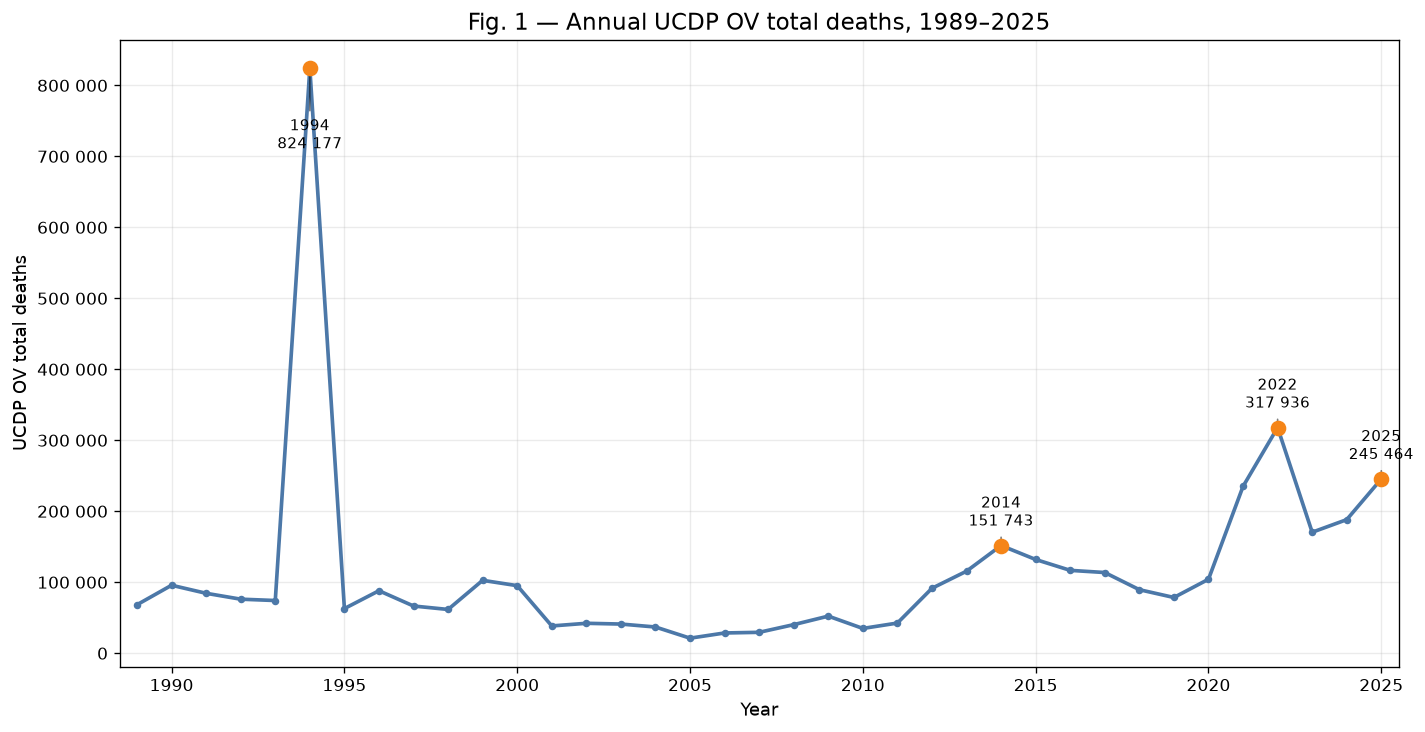

In [4]:
fig, ax = plt.subplots(figsize=(12, 6.2))
ax.plot(annual["year"], annual["ucdp_ov_total_deaths"], linewidth=2.2, marker="o", markersize=3.5, color=PALETTE["blue"])
ax.set_title("Fig. 1 — Annual UCDP OV total deaths, 1989–2025")
ax.set_xlabel("Year")
ax.set_ylabel("UCDP OV total deaths")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: fmt_int(x)))
ax.set_xlim(1988.5, 2025.5)

for year in [1994, 2014, 2022, 2025]:
    row = annual.loc[annual["year"] == year].iloc[0]
    ax.scatter([year], [row["ucdp_ov_total_deaths"]], s=70, color=PALETTE["orange"], zorder=5)
    ax.annotate(
        f"{year}\n{fmt_int(row['ucdp_ov_total_deaths'])}",
        xy=(year, row["ucdp_ov_total_deaths"]),
        xytext=(0, 12 if year != 1994 else -48),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        arrowprops={"arrowstyle": "-", "alpha": 0.5},
    )

fig1_path = save_fig(fig, "fig01_annual_ucdp_ov_total_deaths_1989_2025.png")

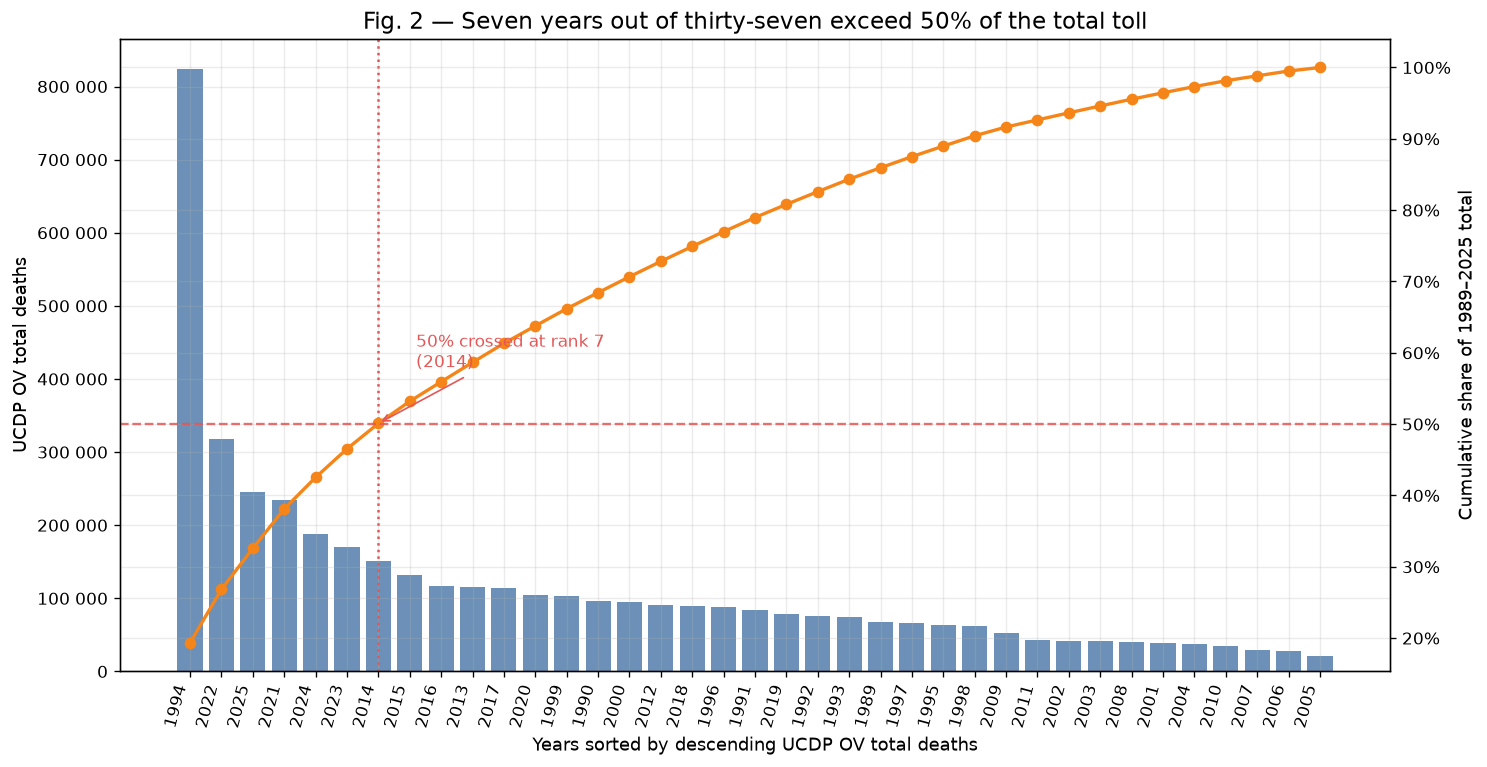

In [5]:
fig, ax1 = plt.subplots(figsize=(12.5, 6.5))
bar_positions = np.arange(len(annual_ranked))
ax1.bar(bar_positions, annual_ranked["ucdp_ov_total_deaths"], color=PALETTE["blue"], alpha=0.82)
ax1.set_title("Fig. 2 — Seven years out of thirty-seven exceed 50% of the total toll")
ax1.set_xlabel("Years sorted by descending UCDP OV total deaths")
ax1.set_ylabel("UCDP OV total deaths")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: fmt_int(x)))
ax1.set_xticks(bar_positions)
ax1.set_xticklabels(annual_ranked["year"].astype(str), rotation=75, ha="right")

ax2 = ax1.twinx()
ax2.plot(bar_positions, annual_ranked["cumulative_share"], color=PALETTE["orange"], marker="o", linewidth=2)
ax2.axhline(0.50, color=PALETTE["red"], linestyle="--", linewidth=1.4, alpha=0.85)
ax2.set_ylabel("Cumulative share of 1989–2025 total")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

threshold_idx = annual_years_to_50 - 1
ax1.axvline(threshold_idx, color=PALETTE["red"], linestyle=":", linewidth=1.5)
ax2.annotate(
    f"50% crossed at rank {annual_years_to_50}\n({int(annual_ranked.loc[threshold_idx, 'year'])})",
    xy=(threshold_idx, annual_ranked.loc[threshold_idx, "cumulative_share"]),
    xytext=(threshold_idx + 1.2, 0.58),
    arrowprops={"arrowstyle": "->", "color": PALETTE["red"]},
    fontsize=10,
    color=PALETTE["red"],
)

fig2_path = save_fig(fig, "fig02_annual_concentration_sorted_bars_cumulative_share.png")

### Observed result — 7 years out of 37 cross 50% of total OV deaths

Across 1989–2025, the panel sums to **4,257,891 UCDP OV total deaths**. Sorting the 37 years by total deaths shows that only **7 years** are needed to exceed 50% of the period total.

The seven years are: **1994, 2022, 2025, 2021, 2024, 2023, 2014**. Together, they sum to **2,132,968 deaths**, or **50.1%** of the 1989–2025 total.

This is the direct validation of the article title. It was recalculated from the panel, not copied from Notebook 03.

<a id="country-year-concentration"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 3</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Country-year concentration</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Validate the unit-year concentration statistics used as supporting evidence.</p>
</div>

In [6]:
positive_unit_years = (
    analysis_conflict[analysis_conflict["ucdp_ov_total_deaths_best_zf"].fillna(0) > 0]
    .sort_values("ucdp_ov_total_deaths_best_zf", ascending=False)
    .reset_index(drop=True)
    .copy()
)
positive_unit_years["rank_desc_total"] = positive_unit_years.index + 1
positive_unit_years["cumulative_deaths"] = positive_unit_years["ucdp_ov_total_deaths_best_zf"].cumsum()
positive_unit_years["cumulative_share"] = positive_unit_years["cumulative_deaths"] / positive_unit_years["ucdp_ov_total_deaths_best_zf"].sum()
unit_years_to_50 = int(positive_unit_years.loc[positive_unit_years["cumulative_share"] >= 0.50, "rank_desc_total"].iloc[0])
unit_years_50 = positive_unit_years.head(unit_years_to_50).copy()

concentration_rows = []
for pct in [0.01, 0.05, 0.10]:
    n = int(math.ceil(len(positive_unit_years) * pct))
    concentration_rows.append({
        "metric": "ucdp_ov_total_deaths_best_zf",
        "positive_unit_years": len(positive_unit_years),
        "top_bucket": f"top_{int(pct * 100)}pct",
        "rows_in_bucket": n,
        "share_of_total": positive_unit_years.head(n)["ucdp_ov_total_deaths_best_zf"].sum() / positive_unit_years["ucdp_ov_total_deaths_best_zf"].sum(),
    })

positive_civilian_unit_years = (
    analysis_conflict[analysis_conflict["ucdp_ov_civilian_deaths_best_zf"].fillna(0) > 0]
    .sort_values("ucdp_ov_civilian_deaths_best_zf", ascending=False)
    .reset_index(drop=True)
    .copy()
)
civ_top_1pct_n = int(math.ceil(len(positive_civilian_unit_years) * 0.01))
concentration_rows.append({
    "metric": "ucdp_ov_civilian_deaths_best_zf",
    "positive_unit_years": len(positive_civilian_unit_years),
    "top_bucket": "top_1pct",
    "rows_in_bucket": civ_top_1pct_n,
    "share_of_total": positive_civilian_unit_years.head(civ_top_1pct_n)["ucdp_ov_civilian_deaths_best_zf"].sum() / positive_civilian_unit_years["ucdp_ov_civilian_deaths_best_zf"].sum(),
})

concentration_by_percentile = pd.DataFrame(concentration_rows)
save_table(concentration_by_percentile, "unit_year_concentration_by_percentile.csv")
save_table(unit_years_50[[
    "rank_desc_total", "analysis_unit_id", "analysis_unit_label", "year", "ucdp_ov_total_deaths_best_zf", "ucdp_ov_civilian_deaths_best_zf", "cumulative_share"
]], "top_unit_years_needed_to_reach_50pct.csv")

display(concentration_by_percentile)
unit_years_50[["rank_desc_total", "analysis_unit_label", "year", "ucdp_ov_total_deaths_best_zf", "cumulative_share"]].tail(8)

,metric,positive_unit_years,top_bucket,rows_in_bucket,share_of_total
0,ucdp_ov_total_deaths_best_zf,2067,top_1pct,21,0.497965
1,ucdp_ov_total_deaths_best_zf,2067,top_5pct,104,0.718574
2,ucdp_ov_total_deaths_best_zf,2067,top_10pct,207,0.818707
3,ucdp_ov_civilian_deaths_best_zf,1730,top_1pct,18,0.695057


,rank_desc_total,analysis_unit_label,year,ucdp_ov_total_deaths_best_zf,cumulative_share
14,15,Ethiopia,2000,48666.0,0.451470
15,16,Syrian Arab Republic,2017,38532.0,0.460520
16,17,Afghanistan,2021,36386.0,0.469066
17,18,"Congo, The Democratic Republic of the",1996,34296.0,0.477120
18,19,Ethiopia,1999,30786.0,0.484351
19,20,Afghanistan,2019,30435.0,0.491498
20,21,Israel,2023,27535.0,0.497965
21,22,Afghanistan,2018,26895.0,0.504282


### Observed result — 22 unit-years carry half the OV total-death signal

Among positive UCDP OV total-death unit-years, only **22 unit-years** are needed to cross 50% of all positive OV deaths. The top **1%** of positive unit-years accounts for **49.8%** of the total; the top **5%** accounts for **71.9%**; and the top **10%** accounts for **81.9%**.

Civilian deaths are even more concentrated: the top **1%** of positive civilian-death unit-years accounts for **69.5%** of all positive OV civilian deaths.

<a id="peak-contributors"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 4</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Peak-year contributors and Israel 2025</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Decompose the peak years while keeping the contributor ≠ perpetrator guardrail explicit.</p>
</div>

### Reading note — contributor does not mean perpetrator

A row such as `Sudan — 2025`, `Ukraine — 2025` or `Israel — 2025` means that deaths are coded under that analytical unit and year in the panel. It does **not** identify perpetrator responsibility, victim nationality, legal classification, event location logic, or target identity. Those questions require actor- and event-level historical analysis.

In [7]:
peak_years = [1994, 2014, 2022, 2025]
peak_tables = []

for year in peak_years:
    sub = analysis_conflict[analysis_conflict["year"] == year].copy()
    annual_total_y = sub["ucdp_ov_total_deaths_best_zf"].sum()
    annual_civilian_y = sub["ucdp_ov_civilian_deaths_best_zf"].sum()
    sub["annual_ov_total_deaths"] = annual_total_y
    sub["annual_ov_civilian_deaths"] = annual_civilian_y
    sub["share_of_annual_total"] = sub["ucdp_ov_total_deaths_best_zf"].fillna(0) / annual_total_y
    sub["share_of_annual_civilian_deaths"] = np.where(
        annual_civilian_y > 0,
        sub["ucdp_ov_civilian_deaths_best_zf"].fillna(0) / annual_civilian_y,
        np.nan,
    )
    sub = sub.sort_values("ucdp_ov_total_deaths_best_zf", ascending=False).reset_index(drop=True)
    sub["rank_in_year"] = sub.index + 1
    peak_tables.append(sub.head(10))

peak_contributors = pd.concat(peak_tables, ignore_index=True)
save_table(peak_contributors[[
    "year", "rank_in_year", "analysis_unit_id", "analysis_unit_label", "ucdp_ov_total_deaths_best_zf",
    "share_of_annual_total", "ucdp_ov_civilian_deaths_best_zf", "share_of_annual_civilian_deaths",
    "annual_ov_total_deaths", "annual_ov_civilian_deaths"
]], "peak_year_top10_contributors.csv")

peak_contributors[[
    "year", "rank_in_year", "analysis_unit_label", "ucdp_ov_total_deaths_best_zf", "share_of_annual_total",
    "ucdp_ov_civilian_deaths_best_zf", "share_of_annual_civilian_deaths"
]].head(40)

,year,rank_in_year,analysis_unit_label,ucdp_ov_total_deaths_best_zf,share_of_annual_total,ucdp_ov_civilian_deaths_best_zf,share_of_annual_civilian_deaths
0,1994,1,Rwanda,772463.0,0.937254,771118.0,0.984792
1,1994,2,Afghanistan,9056.0,0.010988,120.0,0.000153
2,1994,3,Bosnia and Herzegovina,7312.0,0.008872,1241.0,0.001585
3,1994,4,Türkiye,4182.0,0.005074,344.0,0.000439
4,1994,5,Liberia,4167.0,0.005056,3733.0,0.004767
5,1994,6,Angola,4009.0,0.004864,304.0,0.000388
6,1994,7,Sierra Leone,2097.0,0.002544,1551.0,0.001981
7,1994,8,Ghana,2004.0,0.002432,0.0,0.000000
8,1994,9,Algeria,1943.0,0.002358,30.0,0.000038
9,1994,10,Azerbaijan,1489.0,0.001807,10.0,0.000013


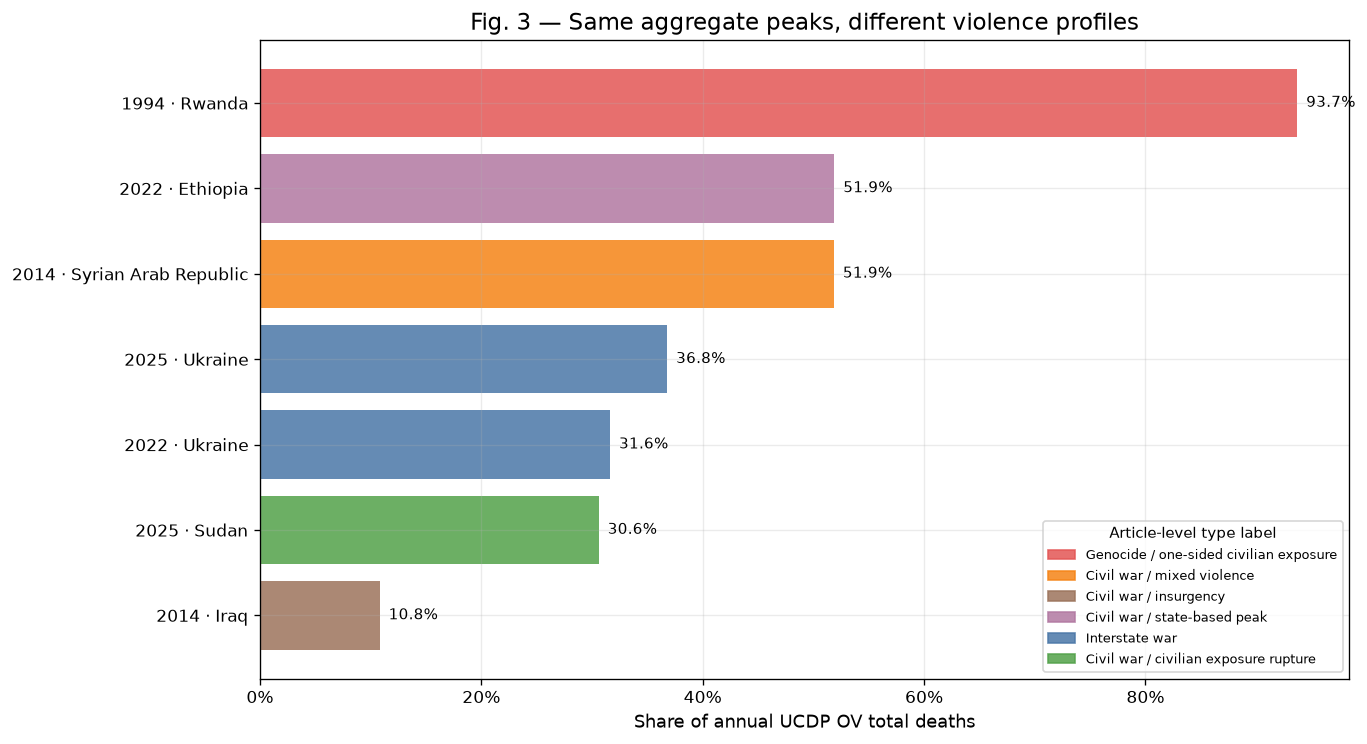

,year,analysis_unit_label,article_type_label,share_of_annual_total
0,1994,Rwanda,Genocide / one-sided civilian exposure,0.937254
10,2014,Syrian Arab Republic,Civil war / mixed violence,0.518699
11,2014,Iraq,Civil war / insurgency,0.108321
20,2022,Ethiopia,Civil war / state-based peak,0.519051
21,2022,Ukraine,Interstate war,0.316428
30,2025,Ukraine,Interstate war,0.368058
31,2025,Sudan,Civil war / civilian exposure rupture,0.306253


In [8]:
story_type_map = {
    (1994, "Rwanda"): "Genocide / one-sided civilian exposure",
    (2014, "Syrian Arab Republic"): "Civil war / mixed violence",
    (2014, "Iraq"): "Civil war / insurgency",
    (2022, "Ethiopia"): "Civil war / state-based peak",
    (2022, "Ukraine"): "Interstate war",
    (2025, "Ukraine"): "Interstate war",
    (2025, "Sudan"): "Civil war / civilian exposure rupture",
}

type_colors = {
    "Genocide / one-sided civilian exposure": PALETTE["red"],
    "Civil war / mixed violence": PALETTE["orange"],
    "Civil war / insurgency": PALETTE["brown"],
    "Civil war / state-based peak": PALETTE["purple"],
    "Interstate war": PALETTE["blue"],
    "Civil war / civilian exposure rupture": PALETTE["green"],
}

story_rows = []
for (year, label), typology in story_type_map.items():
    row = peak_contributors[(peak_contributors["year"] == year) & (peak_contributors["analysis_unit_label"] == label)]
    if row.empty:
        raise AssertionError(f"Missing story contributor: {year} / {label}")
    r = row.iloc[0].copy()
    r["article_type_label"] = typology
    r["story_label"] = f"{year} · {label}"
    story_rows.append(r)

peak_story_contributors = pd.DataFrame(story_rows).sort_values(["year", "share_of_annual_total"], ascending=[True, False])
save_table(peak_story_contributors[[
    "year", "analysis_unit_label", "article_type_label", "ucdp_ov_total_deaths_best_zf", "share_of_annual_total",
    "ucdp_ov_civilian_deaths_best_zf", "share_of_annual_civilian_deaths"
]], "peak_story_contributors_for_article_figure.csv")

fig, ax = plt.subplots(figsize=(11.5, 6.3))
plot_df = peak_story_contributors.sort_values("share_of_annual_total", ascending=True).copy()
colors = [type_colors[label] for label in plot_df["article_type_label"]]
ax.barh(plot_df["story_label"], plot_df["share_of_annual_total"], color=colors, alpha=0.86)
ax.set_title("Fig. 3 — Same aggregate peaks, different violence profiles")
ax.set_xlabel("Share of annual UCDP OV total deaths")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("")

for _, row in plot_df.iterrows():
    ax.text(row["share_of_annual_total"] + 0.008, row["story_label"], f"{fmt_pct(row['share_of_annual_total'])}", va="center", fontsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.86) for color in type_colors.values()]
ax.legend(handles, list(type_colors.keys()), title="Article-level type label", loc="lower right", fontsize=8, title_fontsize=9)
fig3_path = save_fig(fig, "fig03_peak_story_contributors_by_article_type.png")

peak_story_contributors[["year", "analysis_unit_label", "article_type_label", "share_of_annual_total"]]

In [9]:
israel_2025 = peak_contributors[(peak_contributors["year"] == 2025) & (peak_contributors["analysis_unit_label"] == "Israel")].copy()
if israel_2025.empty:
    raise AssertionError("Israel 2025 row not found in the peak contributor table.")

save_table(israel_2025[[
    "year", "rank_in_year", "analysis_unit_label", "ucdp_ov_total_deaths_best_zf", "share_of_annual_total",
    "ucdp_ov_civilian_deaths_best_zf", "share_of_annual_civilian_deaths"
]], "israel_2025_raw_contributor_metrics_only.csv")

israel_2025[[
    "year", "rank_in_year", "analysis_unit_label", "ucdp_ov_total_deaths_best_zf", "share_of_annual_total",
    "ucdp_ov_civilian_deaths_best_zf", "share_of_annual_civilian_deaths"
]]

,year,rank_in_year,analysis_unit_label,ucdp_ov_total_deaths_best_zf,share_of_annual_total,ucdp_ov_civilian_deaths_best_zf,share_of_annual_civilian_deaths
32,2025,3,Israel,14563.0,0.059328,3433.0,0.037492


### Observed result — peak-year decomposition validates the article figures

The peak checks reproduce the article values:

- **1994**: **824,177** total OV deaths; **Rwanda** accounts for **93.7%** of total deaths and **98.5%** of civilian deaths.
- **2014**: **151,743** total OV deaths; **Syrian Arab Republic** accounts for **51.9%**, **Iraq** for **10.8%**.
- **2022**: **317,936** total OV deaths; **Ethiopia** accounts for **51.9%**, **Ukraine** for **31.6%**.
- **2025**: **245,464** total OV deaths; **Ukraine** accounts for **36.8%**, **Sudan** for **30.6%**. Sudan accounts for **72.0%** of civilian deaths in 2025.

**Israel 2025** is validated as the **3rd** statistical contributor in 2025, with **14,563** total OV deaths, **5.9%** of the annual total, and **3,433** civilian deaths. In line with the article guardrail, it is **not** included in the GED type-composition figure.

<a id="ged-composition"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 5</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">GED event composition for selected peaks</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Compute state-based, non-state and one-sided event counts for the six article peak cases.</p>
</div>

In [10]:
ged_cases = pd.DataFrame([
    {"case_label": "Rwanda 1994", "analysis_unit_label": "Rwanda", "year": 1994},
    {"case_label": "Syria 2014", "analysis_unit_label": "Syrian Arab Republic", "year": 2014},
    {"case_label": "Ethiopia 2022", "analysis_unit_label": "Ethiopia", "year": 2022},
    {"case_label": "Ukraine 2022", "analysis_unit_label": "Ukraine", "year": 2022},
    {"case_label": "Ukraine 2025", "analysis_unit_label": "Ukraine", "year": 2025},
    {"case_label": "Sudan 2025", "analysis_unit_label": "Sudan", "year": 2025},
])

ged_rows = []
for _, case in ged_cases.iterrows():
    row = analysis_conflict[
        (analysis_conflict["year"] == int(case["year"]))
        & (analysis_conflict["analysis_unit_label"] == case["analysis_unit_label"])
    ]
    if row.empty:
        raise AssertionError(f"Missing GED case: {case.to_dict()}")
    r = row.iloc[0]
    out = {
        "case_label": case["case_label"],
        "analysis_unit_label": case["analysis_unit_label"],
        "year": int(case["year"]),
        "ged_total_events": r["ucdp_ged_events_zf"],
        "ged_state_based_events": r["ucdp_ged_state_based_events_zf"],
        "ged_non_state_events": r["ucdp_ged_non_state_events_zf"],
        "ged_one_sided_events": r["ucdp_ged_one_sided_events_zf"],
        "ged_best_deaths": r["ucdp_ged_best_deaths_zf"],
        "ged_civilian_deaths": r["ucdp_ged_civilian_deaths_zf"],
        "ov_total_deaths": r["ucdp_ov_total_deaths_best_zf"],
        "ov_civilian_deaths": r["ucdp_ov_civilian_deaths_best_zf"],
    }
    event_sum = out["ged_state_based_events"] + out["ged_non_state_events"] + out["ged_one_sided_events"]
    out["event_type_sum_check"] = event_sum
    out["event_type_sum_matches_total"] = bool(abs(event_sum - out["ged_total_events"]) < 1e-9)
    for col in ["ged_state_based_events", "ged_non_state_events", "ged_one_sided_events"]:
        out[col.replace("events", "share")] = out[col] / out["ged_total_events"] if out["ged_total_events"] else np.nan
    ged_rows.append(out)

ged_composition = pd.DataFrame(ged_rows)
save_table(ged_composition, "ged_event_composition_selected_article_peaks.csv")
ged_composition

,case_label,analysis_unit_label,year,ged_total_events,ged_state_based_events,ged_non_state_events,ged_one_sided_events,ged_best_deaths,ged_civilian_deaths,ov_total_deaths,ov_civilian_deaths,event_type_sum_check,event_type_sum_matches_total,ged_state_based_share,ged_non_state_share,ged_one_sided_share
0,Rwanda 1994,Rwanda,1994,2119.0,57.0,0.0,2062.0,772463.0,771118.0,772463.0,771118.0,2119.0,True,0.026899,0.000000,0.973101
1,Syria 2014,Syrian Arab Republic,2014,16701.0,14253.0,1880.0,568.0,78709.0,18069.0,78709.0,18069.0,16701.0,True,0.853422,0.112568,0.034010
2,Ethiopia 2022,Ethiopia,2022,879.0,699.0,4.0,176.0,165025.0,2442.0,165025.0,2442.0,879.0,True,0.795222,0.004551,0.200228
3,Ukraine 2022,Ukraine,2022,7502.0,7292.0,0.0,210.0,100604.0,19271.0,100604.0,19271.0,7502.0,True,0.972007,0.000000,0.027993
4,Ukraine 2025,Ukraine,2025,7504.0,7496.0,0.0,8.0,90345.0,2635.0,90345.0,2635.0,7504.0,True,0.998934,0.000000,0.001066
5,Sudan 2025,Sudan,2025,718.0,510.0,3.0,205.0,75174.0,65911.0,75174.0,65911.0,718.0,True,0.710306,0.004178,0.285515


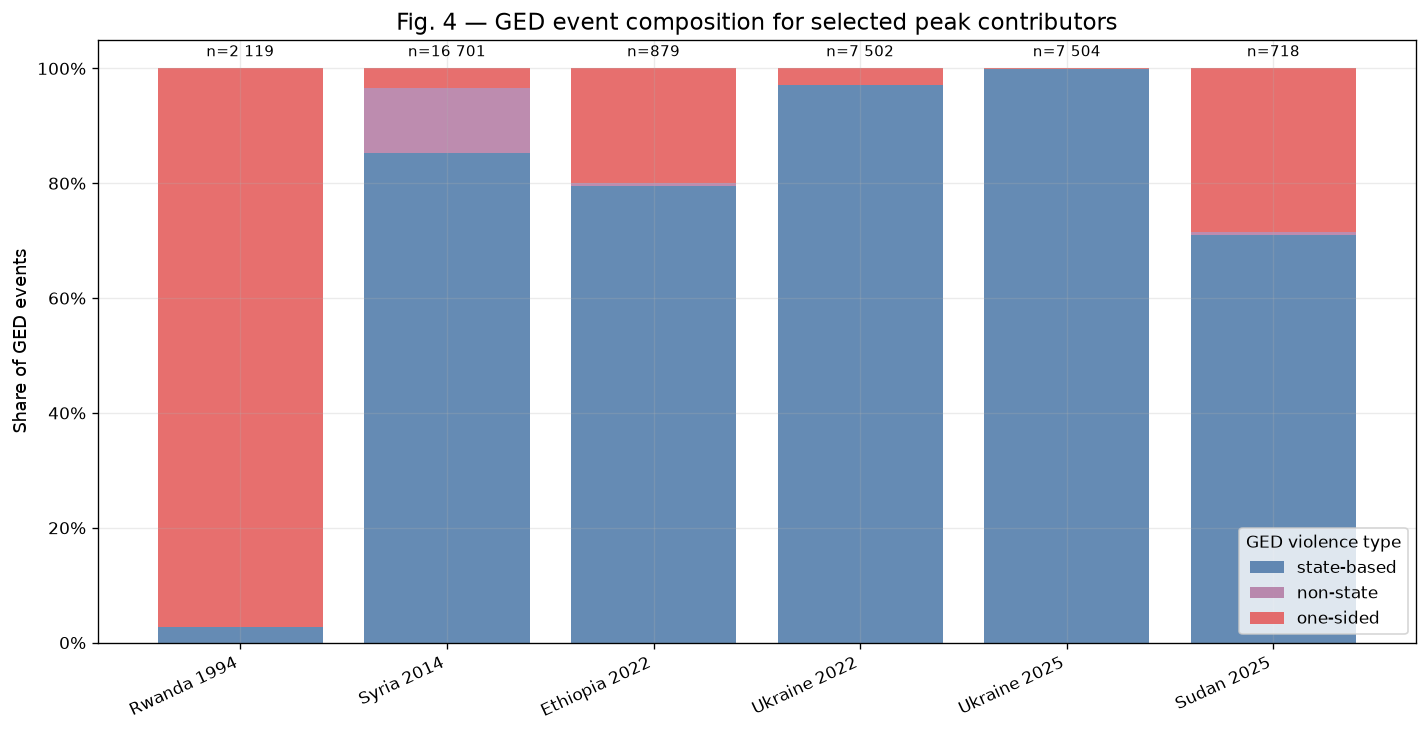

In [11]:
plot_ged = ged_composition.set_index("case_label")[[
    "ged_state_based_share", "ged_non_state_share", "ged_one_sided_share"
]].rename(columns={
    "ged_state_based_share": "state-based",
    "ged_non_state_share": "non-state",
    "ged_one_sided_share": "one-sided",
})

fig, ax = plt.subplots(figsize=(12, 6.2))
bottom = np.zeros(len(plot_ged))
colors = [PALETTE["blue"], PALETTE["purple"], PALETTE["red"]]
for idx, col in enumerate(plot_ged.columns):
    ax.bar(plot_ged.index, plot_ged[col], bottom=bottom, label=col, color=colors[idx], alpha=0.86)
    bottom += plot_ged[col].values

ax.set_title("Fig. 4 — GED event composition for selected peak contributors")
ax.set_ylabel("Share of GED events")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("")
ax.set_xticklabels(plot_ged.index, rotation=25, ha="right")
ax.legend(title="GED violence type")

# Add total-event labels above bars.
for i, (_, row) in enumerate(ged_composition.iterrows()):
    ax.text(i, 1.015, f"n={fmt_int(row['ged_total_events'])}", ha="center", va="bottom", fontsize=9)

fig4_path = save_fig(fig, "fig04_ged_event_composition_selected_peaks.png")

### Observed result — GED composition supports the “same peak, different catastrophe” argument

The six selected peak contributors have sharply different GED event profiles:

- **Rwanda 1994**: **2,119** GED events, overwhelmingly one-sided (**2,062** one-sided events).
- **Syria 2014**: **16,701** GED events, mostly state-based (**14,253**) but with substantial non-state (**1,880**) and one-sided (**568**) components.
- **Ethiopia 2022**: **879** GED events, mostly state-based (**699**) with **176** one-sided events.
- **Ukraine 2022**: **7,502** GED events, almost entirely state-based (**7,292**).
- **Ukraine 2025**: **7,504** GED events, almost entirely state-based (**7,496**).
- **Sudan 2025**: **718** GED events, mostly state-based (**510**) but with a large one-sided component (**205**) relative to the event count.

This figure deliberately excludes Israel 2025 to avoid assigning a violence-type label to that case in the article visuals.

<a id="intensity-diffusion"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 6</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Intensity versus diffusion</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Show that aggregate intensity and number of affected units are distinct dimensions.</p>
</div>

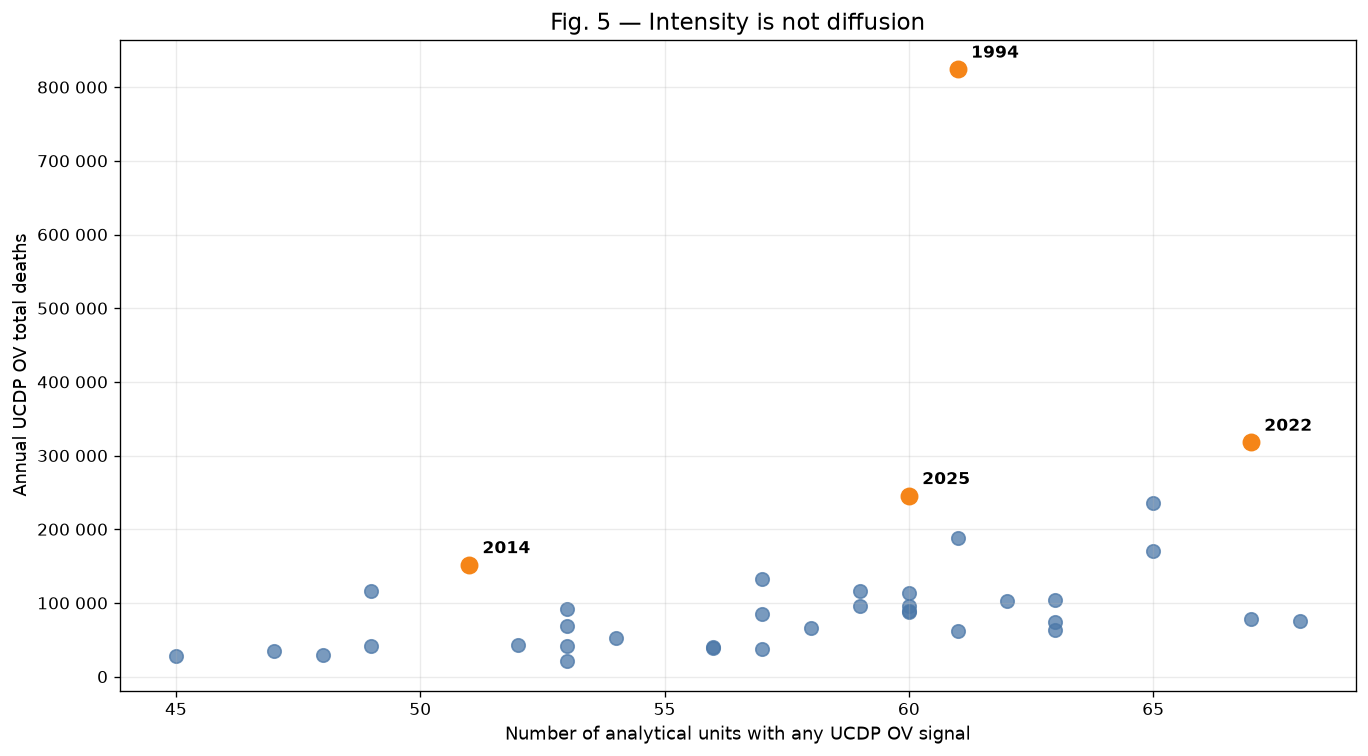

,year,ucdp_ov_total_deaths,units_with_any_ov,units_with_ov_fatalities
count,37.000000,37.000000,37.000000,37.000000
mean,2007.000000,115078.135135,57.621622,55.864865
std,10.824355,136590.941803,5.913033,5.807859
min,1989.000000,21190.000000,45.000000,44.000000
25%,1998.000000,42485.000000,53.000000,51.000000
50%,2007.000000,84408.000000,59.000000,57.000000
75%,2016.000000,115556.000000,61.000000,60.000000
max,2025.000000,824177.000000,68.000000,67.000000


In [12]:
diffusion_summary = annual[["year", "ucdp_ov_total_deaths", "units_with_any_ov", "units_with_ov_fatalities"]].copy()
save_table(diffusion_summary, "annual_intensity_vs_diffusion.csv")

fig, ax = plt.subplots(figsize=(11.5, 6.4))
ax.scatter(diffusion_summary["units_with_any_ov"], diffusion_summary["ucdp_ov_total_deaths"], s=65, color=PALETTE["blue"], alpha=0.75)
ax.set_title("Fig. 5 — Intensity is not diffusion")
ax.set_xlabel("Number of analytical units with any UCDP OV signal")
ax.set_ylabel("Annual UCDP OV total deaths")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: fmt_int(x)))

for year in [1994, 2014, 2022, 2025]:
    row = diffusion_summary.loc[diffusion_summary["year"] == year].iloc[0]
    ax.scatter(row["units_with_any_ov"], row["ucdp_ov_total_deaths"], s=95, color=PALETTE["orange"], zorder=5)
    ax.annotate(
        str(year),
        xy=(row["units_with_any_ov"], row["ucdp_ov_total_deaths"]),
        xytext=(8, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

fig5_path = save_fig(fig, "fig05_intensity_vs_diffusion_scatter.png")

diffusion_summary.describe(include="all")

### Observed result — diffusion stays narrow while intensity varies massively

The annual number of units with any UCDP OV signal ranges from **45** to **68** units per year across 1989–2025. By contrast, annual total deaths range from low tens of thousands to the exceptional **824,177** deaths of 1994.

This confirms the article’s distinction: 1994 is extreme in **intensity**, not because it is the widest year in terms of diffusion. The highest diffusion years are **1992**, **2019** and **2022**, while the 1994 spike is overwhelmingly driven by Rwanda.

<a id="manifest-validation"></a>

<div style="box-sizing:border-box;width:100%;max-width:100%;overflow-x:hidden;white-space:normal;overflow-wrap:anywhere;word-break:normal;margin:44px 0 24px 0;padding:18px 22px;border-radius:10px;background:#102A43;color:white;">
  <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;color:#D4A44C;font-weight:700;">Section 7</div>
  <h2 style="margin:6px 0 0 0;color:white;overflow-wrap:anywhere;word-break:normal;">Export manifest and validation checks</h2>
  <p style='margin:8px 0 0 0;color:#D9E2EC;line-height:1.45;'>Write a compact summary of validated values and assert key article numbers.</p>
</div>

In [13]:
results_summary = {
    "panel_path": str(PANEL_PATH),
    "period": "1989-2025",
    "annual_total_ov_deaths": float(annual_total),
    "annual_years_to_cross_50pct": annual_years_to_50,
    "annual_years_crossing_50pct": annual_years_50["year"].astype(int).tolist(),
    "annual_50pct_cumulative_deaths": float(annual_years_50["ucdp_ov_total_deaths"].sum()),
    "annual_50pct_cumulative_share": float(annual_years_50["ucdp_ov_total_deaths"].sum() / annual_total),
    "unit_years_to_cross_50pct": unit_years_to_50,
    "unit_years_50pct_cumulative_share": float(unit_years_50["ucdp_ov_total_deaths_best_zf"].sum() / positive_unit_years["ucdp_ov_total_deaths_best_zf"].sum()),
    "diffusion_units_any_ov_min": int(diffusion_summary["units_with_any_ov"].min()),
    "diffusion_units_any_ov_max": int(diffusion_summary["units_with_any_ov"].max()),
    "israel_2025_rank": int(israel_2025["rank_in_year"].iloc[0]),
    "israel_2025_total_deaths": float(israel_2025["ucdp_ov_total_deaths_best_zf"].iloc[0]),
    "israel_2025_share_of_annual_total": float(israel_2025["share_of_annual_total"].iloc[0]),
    "israel_2025_civilian_deaths": float(israel_2025["ucdp_ov_civilian_deaths_best_zf"].iloc[0]),
}

results_path = OUTPUT_ROOT / "article_validated_results_summary.json"
results_path.write_text(json.dumps(results_summary, indent=2, ensure_ascii=False), encoding="utf-8")

figure_manifest = pd.DataFrame([
    {"figure": "Fig. 1", "description": "Annual UCDP OV total deaths, 1989–2025", "path": str(fig1_path)},
    {"figure": "Fig. 2", "description": "Annual concentration: sorted years + cumulative share", "path": str(fig2_path)},
    {"figure": "Fig. 3", "description": "Selected peak contributors by article-level type label", "path": str(fig3_path)},
    {"figure": "Fig. 4", "description": "GED event composition for selected peak contributors", "path": str(fig4_path)},
    {"figure": "Fig. 5", "description": "Intensity versus diffusion scatter", "path": str(fig5_path)},
])
save_table(figure_manifest, "figure_manifest.csv")

# Validation checks for the article-critical claims.
assert int(annual_total) == 4_257_891
assert annual_years_to_50 == 7
assert annual_years_50["year"].astype(int).tolist() == [1994, 2022, 2025, 2021, 2024, 2023, 2014]
assert unit_years_to_50 == 22
assert int(annual.loc[annual["year"] == 1994, "ucdp_ov_total_deaths"].iloc[0]) == 824_177
assert int(annual.loc[annual["year"] == 2014, "ucdp_ov_total_deaths"].iloc[0]) == 151_743
assert int(annual.loc[annual["year"] == 2022, "ucdp_ov_total_deaths"].iloc[0]) == 317_936
assert int(annual.loc[annual["year"] == 2025, "ucdp_ov_total_deaths"].iloc[0]) == 245_464
assert int(israel_2025["rank_in_year"].iloc[0]) == 3
assert int(israel_2025["ucdp_ov_total_deaths_best_zf"].iloc[0]) == 14_563

validation_table = pd.DataFrame([
    {"check": "annual total", "status": "passed", "value": fmt_int(annual_total)},
    {"check": "7 years cross 50%", "status": "passed", "value": annual_years_50["year"].astype(int).tolist()},
    {"check": "22 unit-years cross 50%", "status": "passed", "value": unit_years_to_50},
    {"check": "Israel 2025 raw contributor metrics only", "status": "passed", "value": f"rank 3 · {fmt_int(israel_2025['ucdp_ov_total_deaths_best_zf'].iloc[0])} deaths · {fmt_pct(israel_2025['share_of_annual_total'].iloc[0])}"},
    {"check": "figures exported", "status": "passed", "value": len(figure_manifest)},
])
save_table(validation_table, "validation_checks.csv")

display(validation_table)
display(figure_manifest)
display_note(
    "Validation complete.",
    f"All article-critical assertions passed. Summary JSON: <code>{results_path}</code>",
    kind="success",
)

,check,status,value
0,annual total,passed,4 257 891
1,7 years cross 50%,passed,"[1994, 2022, 2025, 2021, 2024, 2023, 2014]"
2,22 unit-years cross 50%,passed,22
3,Israel 2025 raw contributor metrics only,passed,rank 3 · 14 563 deaths · 5.9%
4,figures exported,passed,5


,figure,description,path
0,Fig. 1,"Annual UCDP OV total deaths, 1989–2025",.\03bis_seven_years_article_outputs\figures\fig01_annual_ucdp_ov_total_deaths_1989_2025.png
1,Fig. 2,Annual concentration: sorted years + cumulative share,.\03bis_seven_years_article_outputs\figures\fig02_annual_concentration_sorted_bars_cumulative_share.png
2,Fig. 3,Selected peak contributors by article-level type label,.\03bis_seven_years_article_outputs\figures\fig03_peak_story_contributors_by_article_type.png
3,Fig. 4,GED event composition for selected peak contributors,.\03bis_seven_years_article_outputs\figures\fig04_ged_event_composition_selected_peaks.png
4,Fig. 5,Intensity versus diffusion scatter,.\03bis_seven_years_article_outputs\figures\fig05_intensity_vs_diffusion_scatter.png


## Final synthesis

The dedicated article notebook validates the core claim: a small number of extreme years and unit-years dominate the ConflictLens UCDP OV fatality signal over 1989–2025. The result is not a generic claim that violence is uniformly rising or spreading everywhere. It is a concentration result: **7 years out of 37** cross half the annual total, and **22 positive unit-years** cross half the country-year total-death signal.

The decomposition also supports the article’s methodological caution. The peaks are not interchangeable: Rwanda 1994, Syria 2014, Ethiopia/Ukraine 2022 and Ukraine/Sudan 2025 represent different statistical structures and different GED event compositions. For article wording, the safe phrasing remains: **statistical contributor**, not perpetrator attribution.